In [ ]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)


In [ ]:
X, y = mnist["data"], mnist["target"]

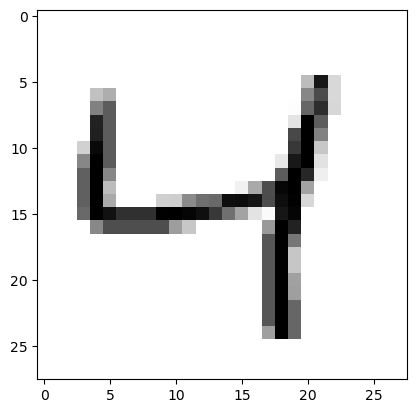

In [23]:
import matplotlib as mpl
import matplotlib.pyplot as plt

digit1 = X[2]
digit2 = X[3]
digit_image1 = digit1.reshape(28,28)
digit_image2 = digit2.reshape(28,28)

plt.imshow(digit_image1, cmap="binary")
plt.show()



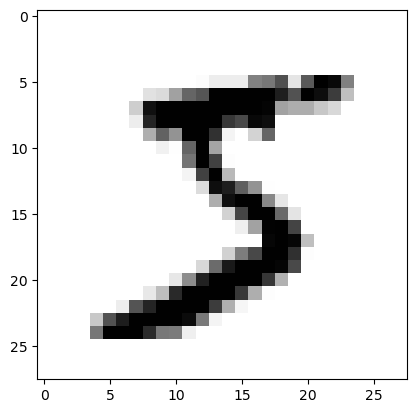

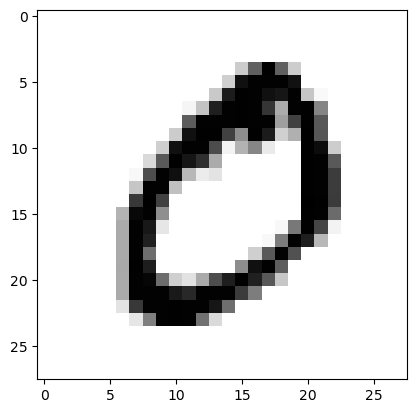

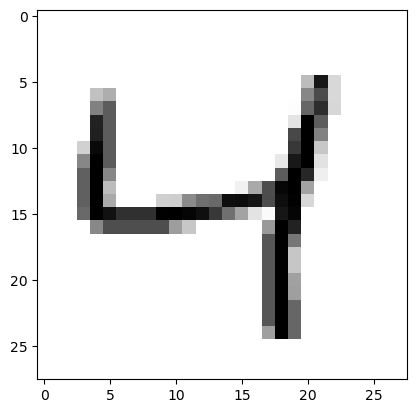

In [32]:
# digit1 = X[2]
# digit2 = X[3]
# digit_image1 = digit1.reshape(28,28)
# digit_image2 = digit2.reshape(28,28)

# plt.imshow([digit_image1, digit_image2], cmap="binary")
# plt.show()


for i in range(3): 
    digit= X[i]
    digit_image = digit.reshape(28,28)
    plt.imshow(digit_image, cmap="binary")
    plt.show()

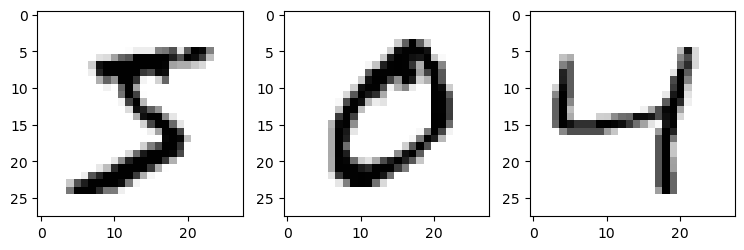

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for i in range(3):
    digit = X[i].reshape(28, 28)
    axes[i].imshow(digit, cmap="binary")
plt.show()

In [35]:
print(y[0])

5


In [ ]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:],  y[:60000], y[60000:]

In [ ]:
y_train_only5 = (y_train == 5)
y_test_only5 = (y_test == 5)

In [ ]:
from sklearn.linear_model import SGDClassifier


sgd_clf = SGDClassifier(random_state = 3)

sgd_clf.fit(X_train, y_train)

In [ ]:
sgd_clf.predict([digit1])


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
skfolds =StratifiedKFold(n_splits=3, shuffle=True)


for train_index, test_index in skfolds.split(X_train, y_train_only5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_only5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_only5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

